In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
import warnings
import shutil

warnings.filterwarnings('ignore')
%matplotlib inline

import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model , Sequential
from tensorflow.keras.layers import Input ,Activation, BatchNormalization, Dropout , Lambda , Conv2D
from tensorflow.keras.layers import MaxPooling2D , concatenate ,Dense, Flatten, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from tensorflow.keras import backend as k
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
from tensorflow import keras
from tensorflow.keras.utils import to_categorical


In [2]:
def img_process(file):
  img = cv2.imread(file)
  img = cv2.resize(img, (128,128))
  img = img/255
  return img

In [3]:
main_path = '/kaggle/input/brain-tumor-mri-dataset/Training'
num = 0
for dir in os.listdir(main_path):
  dir_path = os.path.join(main_path,dir);

  for file in os.listdir(dir_path):
    file_path = os.path.join(dir_path,file)
    num+=1
  print(dir)
  print(num)
  num=0

pituitary
1457
notumor
1595
meningioma
1339
glioma
1321


In [4]:
x=[]
y=[]
i=0
main_path = '/kaggle/input/brain-tumor-mri-dataset/Training'
for dir in os.listdir(main_path):
  dir_path = os.path.join(main_path,dir);

  for file in os.listdir(dir_path):
    file_path = os.path.join(dir_path,file)
    x.append(img_process(file_path))

    y.append(i)
  i+=1
  

y = to_categorical(y,num_classes=4)
x = np.array(x)
y = np.array(y)


In [5]:
x.shape

(5712, 128, 128, 3)

In [6]:

x_test = []
y_test = []
i = 0
main_path2 = '/kaggle/input/brain-tumor-mri-dataset/Testing'

# Iterate over testing data
for dir in os.listdir(main_path2):
    dir_path = os.path.join(main_path2, dir)
    
    for file in os.listdir(dir_path):
        file_path = os.path.join(dir_path, file)
        x_test.append(img_process(file_path))  # Preprocess the test images
        y_test.append(i)  # Append the corresponding label
    i += 1

# Convert to numpy arrays and one-hot encode the labels for the test set
x_test = np.array(x_test)
y_test = np.array(y_test)

# One-hot encode y_test
y_test = to_categorical(y_test, num_classes=4)


In [7]:
x_test.shape

(1311, 128, 128, 3)

In [8]:
x.shape


(5712, 128, 128, 3)

In [9]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
x_train.shape

(4569, 128, 128, 3)

In [11]:
#creating cnn model 32,64,128 filter/layer
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),padding='valid', activation='relu', input_shape=(128,128, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=(2, 2),padding='valid'))

model.add(Conv2D(64, kernel_size=(3, 3),padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=(2, 2),padding='valid'))

model.add(Conv2D(128, kernel_size=(3, 3),padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2),strides=(2, 2),padding='valid'))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(4, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,314,052 (12.64 MB)

 Trainable params: 3,313,604 (12.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [13]:
print(f"x_train shape: {x_train.shape}, dtype: {x_train.dtype}")
print(f"y_train shape: {y_train.shape}, dtype: {y_train.dtype}")
print(f"x_val shape: {x_val.shape}, dtype: {x_val.dtype}")
print(f"y_val shape: {y_val.shape}, dtype: {y_val.dtype}")


x_train shape: (4569, 128, 128, 3), dtype: float64
y_train shape: (4569, 4), dtype: float64
x_val shape: (1143, 128, 128, 3), dtype: float64
y_val shape: (1143, 4), dtype: float64


In [14]:
history = model.fit(
    x_train, 
    y_train, 
    epochs=100, 
    validation_data=(x_val, y_val),  # Use the pre-split validation data
    batch_size=32  # You can adjust batch size as needed
)


Epoch 1/100


I0000 00:00:1734551064.780101      67 service.cc:145] XLA service 0x799a500072e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734551064.780221      67 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 15/143 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4317 - loss: 4.7154

I0000 00:00:1734551070.789938      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


143/143 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.6277 - loss: 2.0836 - val_accuracy: 0.3526 - val_loss: 2.8441
Epoch 2/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7799 - loss: 0.6243 - val_accuracy: 0.6702 - val_loss: 0.8910
Epoch 3/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8376 - loss: 0.4760 - val_accuracy: 0.7682 - val_loss: 0.6538
Epoch 4/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8590 - loss: 0.3910 - val_accuracy: 0.8443 - val_loss: 0.4902
Epoch 5/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9002 - loss: 0.2798 - val_accuracy: 0.8653 - val_loss: 0.4673
Epoch 6/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9085 - loss: 0.2476 - val_accuracy: 0.9143 - val_loss: 0.3096
Epoch 7/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9335 - loss: 0.2070 - val_accuracy: 0.8871 - val_loss: 0.3062
Epoch 8/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9369 - loss: 0.1868 - val_accurac

In [15]:
x_test.shape

(1311, 128, 128, 3)

In [16]:
y_test.shape

(1311, 4)

In [17]:
model.evaluate(x_test,y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9834 - loss: 0.2310


[0.5509870052337646, 0.9610983729362488]

In [18]:
model.save("/kaggle/working/model.h5")

In [19]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/kaggle/input/oldmodel/tensorflow2/default/1/oldmodelBrain.h5")
loaded_model

<Sequential name=sequential, built=True>

In [20]:
loaded_model.evaluate(x_test,y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9681 - loss: 0.2269


[0.3673408627510071, 0.9488939642906189]

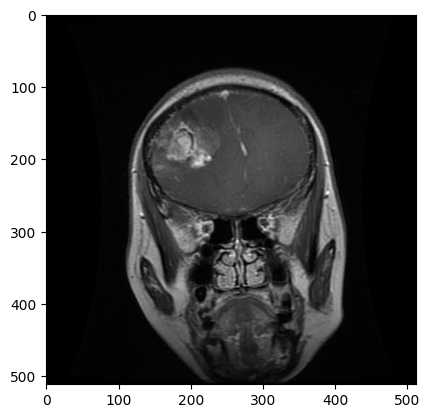

In [21]:
test_img=cv2.imread('/kaggle/input/brain-tumor-mri-dataset/Training/glioma/Tr-glTr_0000.jpg')
plt.imshow(test_img)

In [22]:
category={
    0:"pituitary",
    1:"notumor",
    2:"meningioma",
    3:"glioma"
}
img = img_process("/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-noTr_0000.jpg")  # Same preprocessing as training
img = np.expand_dims(img, axis=0)  # Add batch dimension
prediction = model.predict(img)
predicted_class = np.argmax(prediction, axis=1)
print(category[predicted_class[0]])
print(f'{prediction[0][predicted_class[0]]*100} %')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
notumor
100.0 %


In [23]:
img.shape


(1, 128, 128, 3)

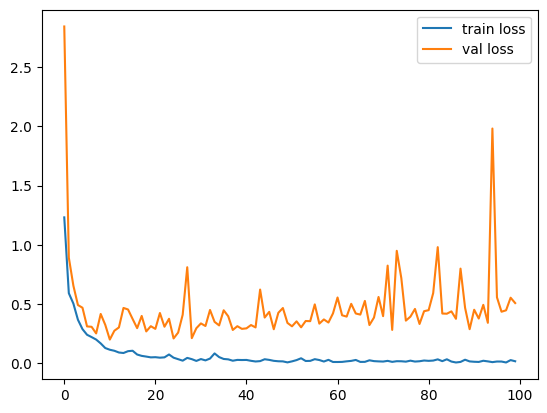

In [24]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

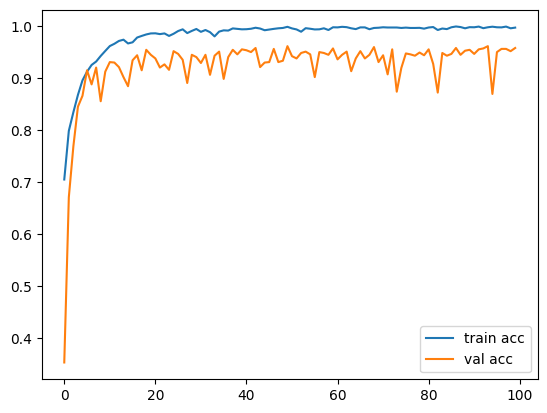

In [25]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [26]:
x_test.shape

(1311, 128, 128, 3)

In [27]:
x_train.shape

(4569, 128, 128, 3)

In [28]:
x_test.shape

(1311, 128, 128, 3)

In [29]:
x_val.shape

(1143, 128, 128, 3)

In [30]:
y_train.shape

(4569, 4)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


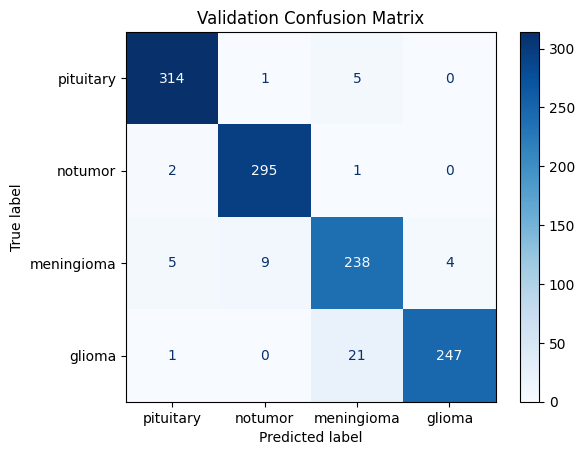

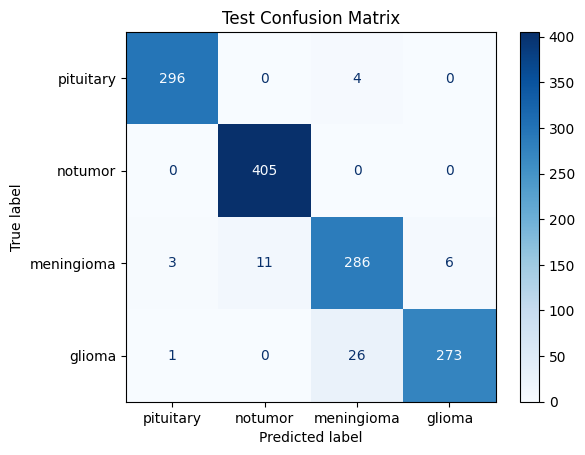

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

category = {
    0: "pituitary",
    1: "notumor",
    2: "meningioma",
    3: "glioma"
}


class_names = [category[i] for i in range(len(category))]


y_val_pred = model.predict(x_val)  
y_test_pred = model.predict(x_test)  


y_val_pred_classes = np.argmax(y_val_pred, axis=1)  
y_test_pred_classes = np.argmax(y_test_pred, axis=1)  

val_conf_matrix = confusion_matrix(np.argmax(y_val, axis=1), y_val_pred_classes) 
test_conf_matrix = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred_classes)  


def plot_confusion_matrix(conf_matrix, class_names, title):
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='horizontal')
    plt.title(title)
    plt.show()


plot_confusion_matrix(val_conf_matrix, class_names, title="Validation Confusion Matrix")


plot_confusion_matrix(test_conf_matrix, class_names, title="Test Confusion Matrix")


In [32]:
from sklearn.metrics import classification_report


y_val_pred = model.predict(x_val)  
y_test_pred = model.predict(x_test) 


y_val_pred_classes = np.argmax(y_val_pred, axis=1)  
y_test_pred_classes = np.argmax(y_test_pred, axis=1)  


val_report = classification_report(np.argmax(y_val, axis=1), y_val_pred_classes, target_names=class_names)
test_report = classification_report(np.argmax(y_test, axis=1), y_test_pred_classes, target_names=class_names)


print("Validation Classification Report:")
print(val_report)

print("Test Classification Report:")
print(test_report)


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Validation Classification Report:
              precision    recall  f1-score   support

   pituitary       0.98      0.98      0.98       320
     notumor       0.97      0.99      0.98       298
  meningioma       0.90      0.93      0.91       256
      glioma       0.98      0.92      0.95       269

    accuracy                           0.96      1143
   macro avg       0.96      0.95      0.96      1143
weighted avg       0.96      0.96      0.96      1143

Test Classification Report:
              precision    recall  f1-score   support

   pituitary       0.99      0.99      0.99       300
     notumor       0.97      1.00      0.99       405
  meningioma       0.91      0.93      0.92       306
      glioma       0.98      0.91      0.94       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96  

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


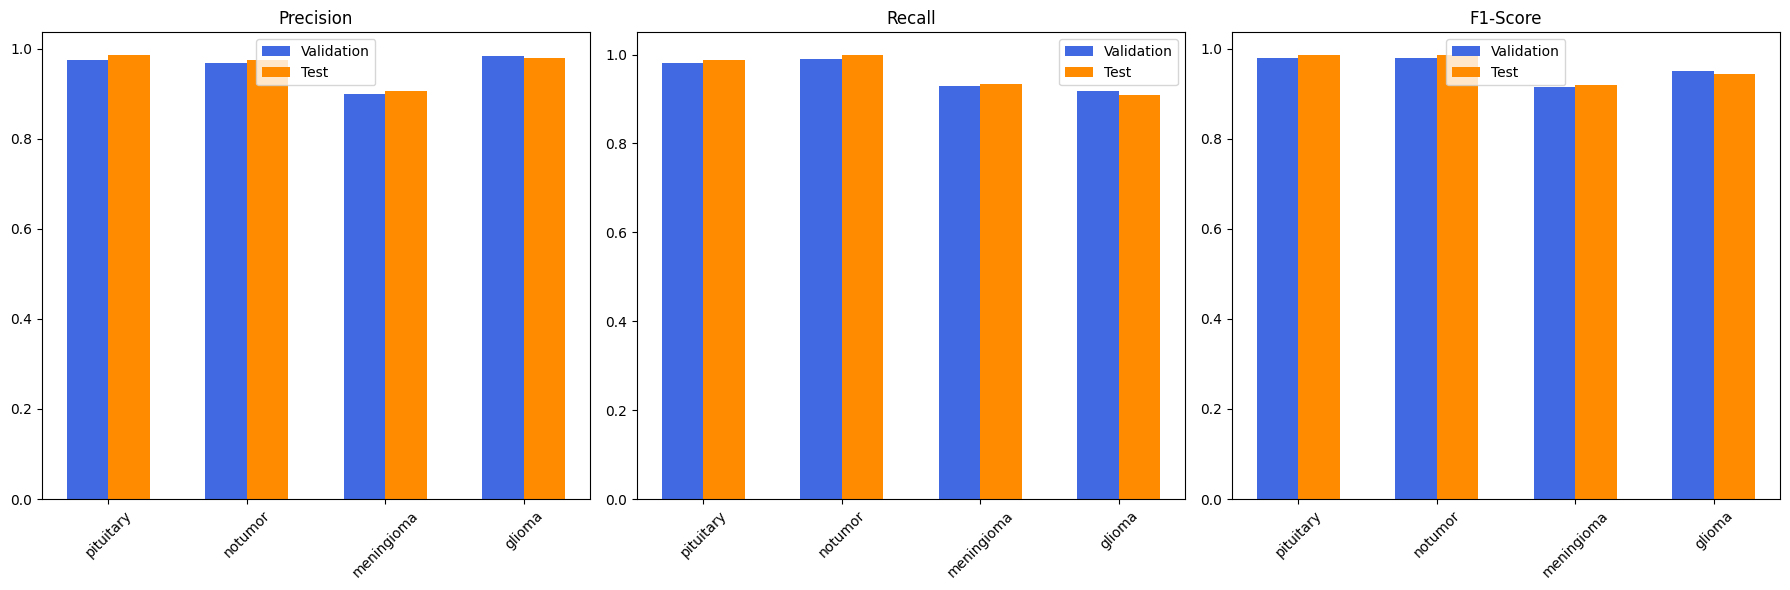

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import numpy as np



y_val_pred = model.predict(x_val)  
y_test_pred = model.predict(x_test)

y_val_pred_classes = np.argmax(y_val_pred, axis=1)  
y_test_pred_classes = np.argmax(y_test_pred, axis=1)  


val_report = classification_report(np.argmax(y_val, axis=1), y_val_pred_classes, target_names=class_names, output_dict=True)
test_report = classification_report(np.argmax(y_test, axis=1), y_test_pred_classes, target_names=class_names, output_dict=True)


val_precision = [val_report[class_name]['precision'] for class_name in class_names]
val_recall = [val_report[class_name]['recall'] for class_name in class_names]
val_f1score = [val_report[class_name]['f1-score'] for class_name in class_names]

test_precision = [test_report[class_name]['precision'] for class_name in class_names]
test_recall = [test_report[class_name]['recall'] for class_name in class_names]
test_f1score = [test_report[class_name]['f1-score'] for class_name in class_names]


x = np.arange(len(class_names)) 


width = 0.3

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


axes[0].bar(x - width / 2, val_precision, width, label='Validation', color='royalblue')
axes[0].bar(x + width / 2, test_precision, width, label='Test', color='darkorange')
axes[0].set_title('Precision')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45)
axes[0].legend()


axes[1].bar(x - width / 2, val_recall, width, label='Validation', color='royalblue')
axes[1].bar(x + width / 2, test_recall, width, label='Test', color='darkorange')
axes[1].set_title('Recall')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45)
axes[1].legend()


axes[2].bar(x - width / 2, val_f1score, width, label='Validation', color='royalblue')
axes[2].bar(x + width / 2, test_f1score, width, label='Test', color='darkorange')
axes[2].set_title('F1-Score')
axes[2].set_xticks(x)
axes[2].set_xticklabels(class_names, rotation=45)
axes[2].legend()


plt.tight_layout()
plt.show()


In [34]:
model.save("/kaggle/working/modelfinal.h5")